In [10]:
from ollama import chat
import time
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import clip
import torch
import cv2
import numpy as np
from PIL import Image
from  matplotlib import pyplot as plt
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchvision.transforms import InterpolationMode
BICUBIC = InterpolationMode.BICUBIC
from ultralytics import SAM

In [11]:
img_path = "image.png"

In [64]:
task = "Find cars"

In [75]:
start = time.perf_counter()

response = chat(
    model="qwen2.5vl:3b",
    messages=[
        {
            "role": "user",
            "content": f"""
                Generate labels for open-vocabulary localization from aerial or satellite imagery for the mission objective: {task}

                Rules:
                - Labels must correspond to large visually distinct regions.
                - Include all major visible categories, not just the most important ones.
                - Do not include parts or subtypes of another label.
                - Merge semantically similar categories.
                - If road, sidewalk, driveway, parking lot, or other traversable paved surfaces are present, output only "road".
                - If houses or buildings are present, output only "building".
                - If dense contiguous tree canopy is present, output "forest".
                - If large open grassy or agricultural areas are present, output "field".
                - Do not merge forest, field, or vegetation into a single category.
                - Roads are high-priority categories and should always be included when visible.
                - For each label, generate localization synonyms as a single '+'-separated string.
                - The synonyms string must always start with the canonical label itself.
                - Include a mission relevance score from 0-100.
                - Relevance reflects mission usefulness, not detection confidence.
                - Return valid JSON only. The response must begin with '{' and end with '}'. No markdown, code fences, comments, or additional text.

                {{
                    "road": {{
                        "synonyms": ["road+street+pavement"],
                        "relevance": 95
                    }},
                }}
                """,
            "images": [f"{img_path}"],
        }
    ],
)

end = time.perf_counter()


print(f"\nInference time: {end - start:.2f} seconds")



Inference time: 1.59 seconds


In [76]:

import json

print(response["message"]["content"])

data = json.loads(response["message"]["content"])

texts = []

for label_data in data.values():
    texts.extend(
        s.strip().lower()
        for s in label_data["synonyms"]
    )

texts = list(dict.fromkeys(texts))

print(texts)


{
    "road": {
        "synonyms": ["road+street+pavement"],
        "relevance": 95
    },
    "building": {
        "synonyms": ["house+structure"],
        "relevance": 80
    },
    "forest": {
        "synonyms": ["trees+dense"],
        "relevance": 75
    },
    "field": {
        "synonyms": ["grass+yielded"],
        "relevance": 90
    }
}
['road+street+pavement', 'house+structure', 'trees+dense', 'grass+yielded']


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, _ = clip.load("CS-ViT-B/16", device=device)
model.eval()
preprocess =  Compose([Resize((512, 512), interpolation=BICUBIC), ToTensor(),
    Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))])

In [14]:
pil_img = Image.open(img_path).convert("RGB")
cv2_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
image = preprocess(pil_img).unsqueeze(0).to(device)

In [126]:
# Init Ultralytics MobileSAM, a lightweight SAM implementation.
sam = SAM("mobile_sam.pt")
sam_image = np.array(pil_img)


def predict_sam_mask(point_coords, point_labels, multimask_output=True):
    point_coords = np.asarray(point_coords, dtype=np.float32)
    point_labels = np.asarray(point_labels, dtype=np.int32)
    if point_coords.size == 0:
        return np.zeros(cv2_img.shape[:2], dtype=np.uint8)

    results = sam.predict(
        source=sam_image,
        points=[point_coords.tolist()],
        labels=[point_labels.tolist()],
        retina_masks=True,
        device=device,
        verbose=False,
    )
    masks = results[0].masks
    if masks is None or len(masks.data) == 0:
        return np.zeros(cv2_img.shape[:2], dtype=np.uint8)

    scores = results[0].boxes.conf if results[0].boxes is not None else None
    # mask_idx = int(torch.argmax(scores)) if scores is not None and len(scores) else 0
    # mask = masks.data[mask_idx].detach().cpu().numpy()
    # return mask.astype('uint8')

    if masks is None or len(masks.data) == 0:
        return []

    return [
        mask.detach().cpu().numpy().astype("uint8")
        for mask in masks.data
    ]

In [57]:
prompt_templates = [
    "aerial imagery of {}.",
    "aerial imagery of {}s.",
    "an aerial image of {}.",
    "an aerial image of {}s.",
    "a satellite image of {}.",
    "a satellite image of {}s.",
    "an overhead view of {}.",
    "an overhead view of {}s.",
    "{} seen from above.",
    "{}s seen from above.",
    "{} in aerial imagery.",
    "{}s in aerial imagery.",
    "{} in satellite imagery.",
    "{}s in satellite imagery.",
    "there is {} in the aerial scene.",
    "there are {}s in the aerial scene.",
]

CLIP Surgery for a single text: road+street+pavement


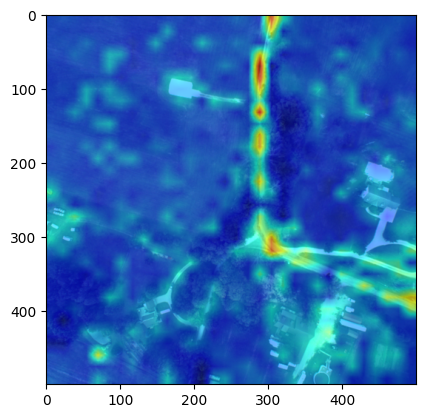

CLIP Surgery for a single text: house+structure


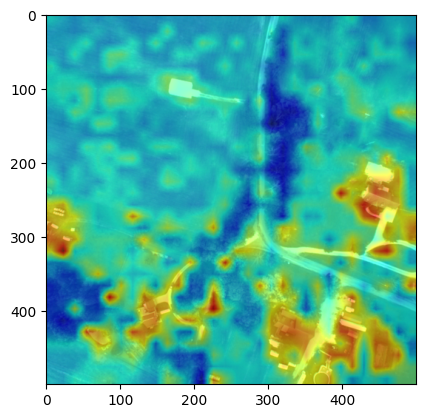

CLIP Surgery for a single text: trees+dense


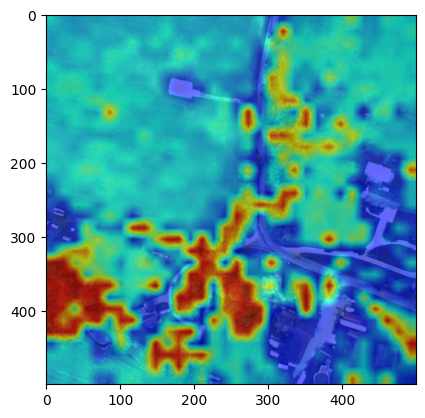

CLIP Surgery for a single text: grass+yielded


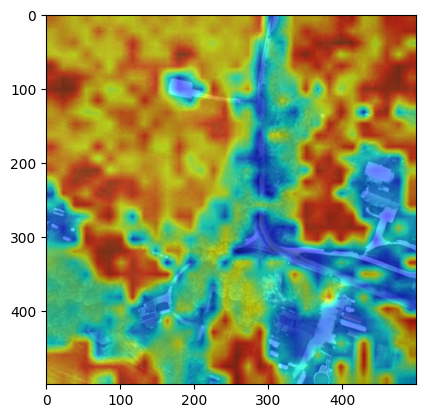

In [104]:
with torch.no_grad():
    # CLIP architecture surgery acts on the image encoder
    image_features = model.encode_image(image)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    # Prompt ensemble for text features with normalization
    text_features = clip.encode_text_with_prompt_ensemble(model, texts, device, prompt_templates=prompt_templates)

    # Extract redundant features from an empty string
    redundant_features = clip.encode_text_with_prompt_ensemble(model, [""], device, prompt_templates=prompt_templates)

    # Apply feature surgery for single text
    similarity = clip.clip_feature_surgery(image_features, text_features, redundant_features)
    similarity_map = clip.get_similarity_map(similarity[:, 1:, :], cv2_img.shape[:2])

    # Draw similarity map
    for b in range(similarity_map.shape[0]):
        for n in range(similarity_map.shape[-1]):
            vis = similarity_map[b, :, :, n].cpu().numpy()

            # kernel = np.ones((21, 21), np.uint8)
            # vis = cv2.dilate(vis, kernel, iterations=1)
            vis = (vis * 255).astype("uint8")
            # binary = vis > 80
            # masked = np.zeros_like(cv2_img)
            # masked[binary] = cv2_img[binary]
            # masked = cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)
            # num_labels, labels = cv2.connectedComponents(binary.astype(np.uint8), connectivity=8)

            vis = cv2.applyColorMap(vis, cv2.COLORMAP_JET)
            vis = cv2_img * 0.4 + vis * 0.6
            vis = cv2.cvtColor(vis.astype('uint8'), cv2.COLOR_BGR2RGB)
            print('CLIP Surgery for a single text:', texts[n])
            plt.imshow(vis)
            plt.show()

In [110]:
from sklearn.cluster import DBSCAN


1
SAM & CLIP Surgery: road+street+pavement (mask 0)


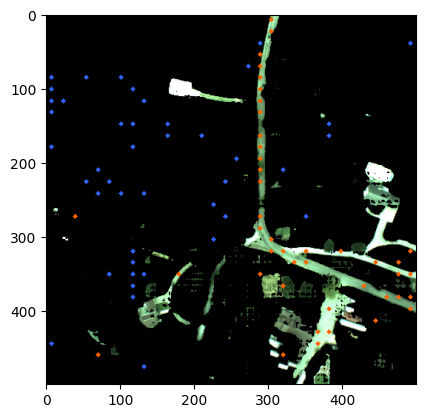

In [134]:
with torch.no_grad():
    # CLIP architecture surgery acts on the image encoder
    image_features = model.encode_image(image)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    # Prompt ensemble for text features with normalization
    text_features = clip.encode_text_with_prompt_ensemble(
        model,
        texts,
        device
    )

    # Extract redundant features from an empty string
    redundant_features = clip.encode_text_with_prompt_ensemble(
        model,
        [""],
        device
    )

    # CLIP feature surgery with custom redundant features
    similarity = clip.clip_feature_surgery(
        image_features,
        text_features,
        redundant_features
    )[0]

    for idx, text in enumerate(texts):

        # Inference SAM with points from CLIP Surgery
        points, labels = clip.similarity_map_to_points(
            similarity[1:, idx],
            cv2_img.shape[:2],
            t=0.4,
            down_sample=1
        )

        num_pos = np.sum(labels == 1)
        if num_pos > 50: continue

        masks = predict_sam_mask(points, labels)
        print(len(masks))

        for mask_idx, mask in enumerate(masks):

            vis = cv2_img.copy()

            vis[mask < 1] = 0

            for i, (x, y) in enumerate(points):
                cv2.circle(
                    vis,
                    (x, y),
                    1,
                    (0, 102, 255) if labels[i] == 1 else (255, 102, 51),
                    3
                )

            vis = cv2.cvtColor(
                vis.astype("uint8"),
                cv2.COLOR_BGR2RGB
            )

            print(f"SAM & CLIP Surgery: {text} (mask {mask_idx})")
            plt.imshow(vis)
            plt.show()

DBSCAN + Convex Hull: house+structure


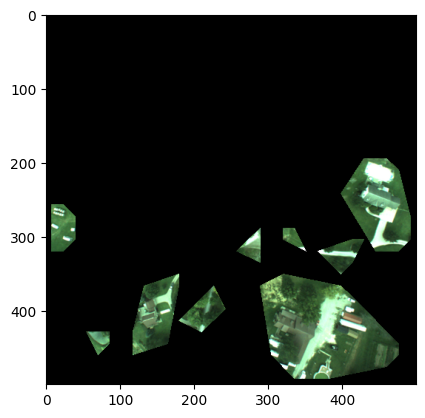

DBSCAN + Convex Hull: trees+dense


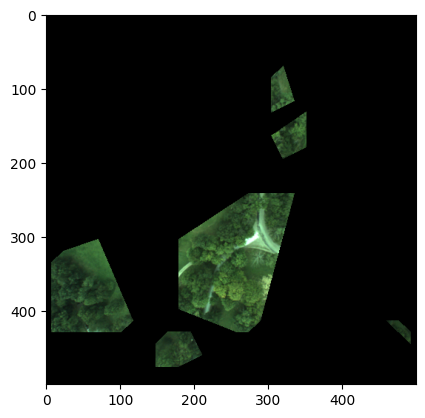

DBSCAN + Convex Hull: grass+yielded


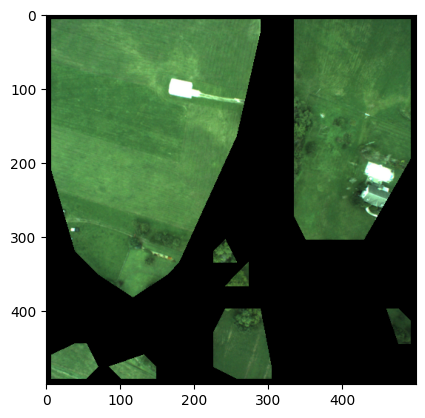

In [124]:
with torch.no_grad():
    image_features = model.encode_image(image)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    text_features = clip.encode_text_with_prompt_ensemble(
        model,
        texts,
        device
    )

    redundant_features = clip.encode_text_with_prompt_ensemble(
        model,
        [""],
        device
    )

    similarity = clip.clip_feature_surgery(
        image_features,
        text_features,
        redundant_features
    )[0]

    for idx, text in enumerate(texts):

        points, labels = clip.similarity_map_to_points(
            similarity[1:, idx],
            cv2_img.shape[:2],
            t=0.5,
            down_sample=1
        )

        num_pos = np.sum(labels == 1)
        if num_pos < 50: continue

        pos_points = np.array([
            p for p, l in zip(points, labels)
            if l == 1
        ], dtype=np.int32)

        vis = cv2_img.copy()

        if len(pos_points) >= 3:

            clusters = DBSCAN(
                eps=25,
                min_samples=5
            ).fit(pos_points)

            mask = np.zeros(
                cv2_img.shape[:2],
                dtype=np.uint8
            )

            for cluster_id in np.unique(clusters.labels_):

                if cluster_id == -1:
                    continue

                cluster_points = pos_points[
                    clusters.labels_ == cluster_id
                ]

                if len(cluster_points) < 3:
                    continue

                hull = cv2.convexHull(cluster_points)

                cv2.fillConvexPoly(
                    mask,
                    hull,
                    255
                )

            vis[mask == 0] = 0

        vis = cv2.cvtColor(
            vis.astype("uint8"),
            cv2.COLOR_BGR2RGB
        )

        print(f"DBSCAN + Convex Hull: {text}")
        plt.imshow(vis)
        plt.show()